# Diabetes Risk Prediction Using Explainable AI

## Project Overview

Diabetes is a major public health issue. Early identification of people who may be at risk can help healthcare providers and public health organisations plan better prevention strategies.

This project uses health, lifestyle, and demographic indicators to predict whether a person is at risk of diabetes. The project also applies Explainable AI methods, such as SHAP and LIME, to understand which factors influence the model's predictions.

The goal is not only to build a machine learning model, but also to explain the model’s decisions in a way that can be understood by non-technical stakeholders.

In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# XAI libraries
import shap
from lime.lime_tabular import LimeTabularExplainer

# Display settings
pd.set_option("display.max_columns", None)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the dataset
# The data file is loaded with a relative path so the notebook runs on any machine.
import os

_candidate_paths = [
    "diabetes_cleaned.csv",
    "data/diabetes_cleaned.csv",
    "../data/diabetes_cleaned.csv",
    "data/diabetes_012_health_indicators_BRFSS2015.csv",
    "diabetes_012_health_indicators_BRFSS2015.csv",
]
_data_path = next((p for p in _candidate_paths if os.path.exists(p)), None)
if _data_path is None:
    raise FileNotFoundError("Dataset not found. Place the CSV in the data/ folder.")

df = pd.read_csv(_data_path)

# Display the first five rows
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0,0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0,0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0,0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0,0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0,0


In [3]:
# Check the number of rows and columns
df.shape

(253680, 23)

In [4]:
# Check column names
df.columns

Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income',
       'Diabetes_binary'],
      dtype='str')

## Dataset Description

The dataset used in this project is the Diabetes Health Indicators dataset from the Behavioral Risk Factor Surveillance System.

The dataset contains health, lifestyle, and demographic variables. These include blood pressure, cholesterol, BMI, smoking status, physical activity, general health, age, education, and income.

The original target variable is `Diabetes_012`, where:

- 0 = No diabetes
- 1 = Prediabetes
- 2 = Diabetes

Since the prediabetes class is much smaller than the other classes, this project converts the task into a binary classification problem:

- 0 = No diabetes
- 1 = Prediabetes or diabetes risk

In [5]:
# Create a binary target variable
# 0 = No diabetes
# 1 = Prediabetes or diabetes

df["Diabetes_binary"] = df["Diabetes_012"].replace({
    0: 0,
    1: 1,
    2: 1
})

# Check the new target distribution
df["Diabetes_binary"].value_counts()

Diabetes_binary
0.0    213703
1.0     39977
Name: count, dtype: int64

In [6]:
# Check target distribution as percentages
df["Diabetes_binary"].value_counts(normalize=True) * 100

Diabetes_binary
0.0    84.24117
1.0    15.75883
Name: proportion, dtype: float64

## Target Variable Transformation

The original target variable had three classes: no diabetes, prediabetes, and diabetes. However, the prediabetes group is much smaller than the other groups, which can make multiclass classification difficult.

To make the problem more practical and easier to interpret, the target was converted into a binary classification problem. Individuals with prediabetes or diabetes were grouped together as the "at risk" group.

This allows the model to answer a clear healthcare question:

**Can we identify individuals who may be at risk of diabetes based on their health indicators?**

In [7]:
# Set visual style
sns.set_theme(style="whitegrid")

# Custom project colour palette
blue = "#1f77b4"
orange = "#ff7f0e"
yellow = "#f2c94c"

project_palette = [blue, orange, yellow]

# Palette for diabetes risk classes
risk_palette = {
    0: blue,
    1: orange
}

## Exploratory Data Analysis

This section explores the main patterns in the dataset before modelling. The goal is to understand how diabetes risk is related to health, lifestyle, and demographic indicators such as BMI, blood pressure, cholesterol, physical activity, general health, age, education, and income.



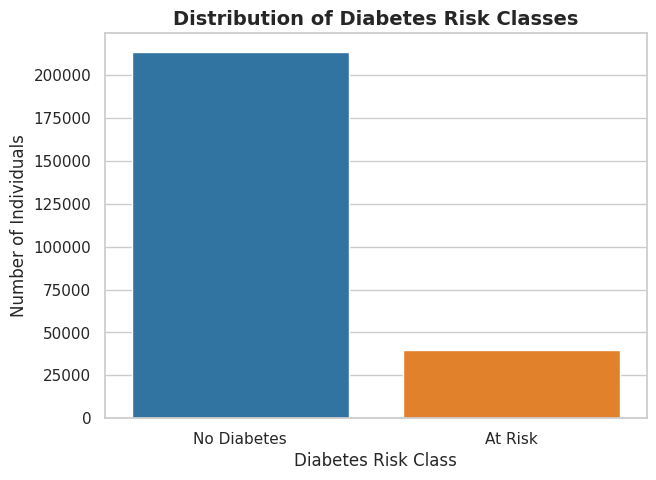

In [8]:
# Make sure the target column is stored as integers
df["Diabetes_binary"] = df["Diabetes_binary"].astype(int)
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Diabetes_binary",
    palette={"0": blue, "1": orange}
)

plt.title("Distribution of Diabetes Risk Classes", fontsize=14, fontweight="bold")
plt.xlabel("Diabetes Risk Class")
plt.ylabel("Number of Individuals")
plt.xticks([0, 1], ["No Diabetes", "At Risk"])

plt.show()



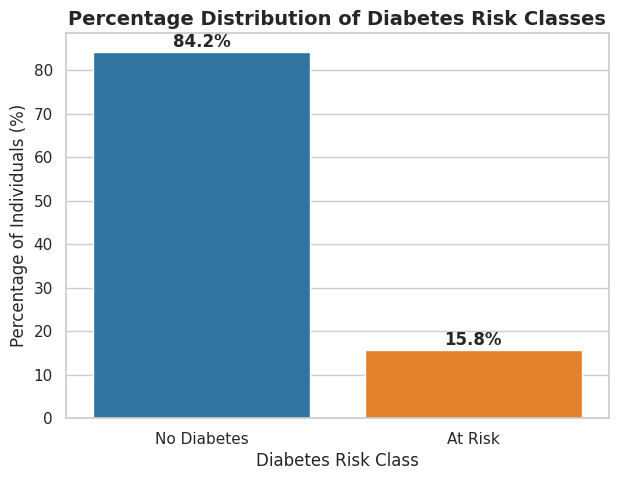

In [9]:
target_percentages = (
    df["Diabetes_binary"]
    .value_counts(normalize=True)
    .reset_index()
)

target_percentages.columns = ["Diabetes_binary", "Percentage"]
target_percentages["Percentage"] = target_percentages["Percentage"] * 100

plt.figure(figsize=(7, 5))

sns.barplot(
    data=target_percentages,
    x="Diabetes_binary",
    y="Percentage",
    palette=[blue, orange]
)

plt.title("Percentage Distribution of Diabetes Risk Classes", fontsize=14, fontweight="bold")
plt.xlabel("Diabetes Risk Class")
plt.ylabel("Percentage of Individuals (%)")
plt.xticks([0, 1], ["No Diabetes", "At Risk"])

for index, row in target_percentages.iterrows():
    plt.text(
        index,
        row["Percentage"] + 1,
        f"{row['Percentage']:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.show()


The percentage distribution confirms that the diabetes-risk group is much smaller than the no-diabetes group. This class imbalance needs to be considered when training and evaluating the machine learning models.

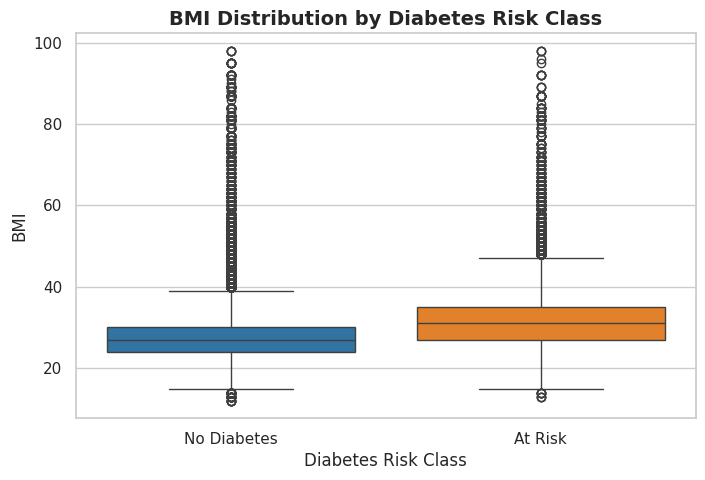

In [10]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Diabetes_binary",
    y="BMI",
    order=[0, 1],
    palette=[blue, orange]
)

plt.title("BMI Distribution by Diabetes Risk Class", fontsize=14, fontweight="bold")
plt.xlabel("Diabetes Risk Class")
plt.ylabel("BMI")
plt.xticks([0, 1], ["No Diabetes", "At Risk"])

plt.show()


This boxplot compares BMI values for individuals with no diabetes and individuals at risk of diabetes. If the at-risk group has a higher median BMI, this suggests that BMI may be an important factor for predicting diabetes risk.

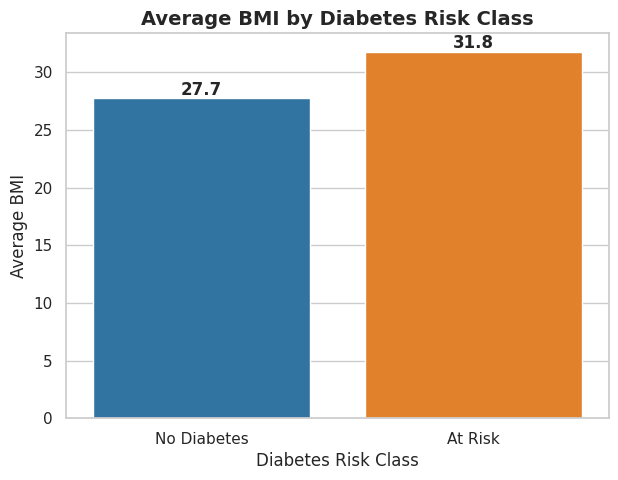

In [11]:
bmi_summary = (
    df.groupby("Diabetes_binary")["BMI"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(7, 5))


sns.barplot(
    data=bmi_summary,
    x="Diabetes_binary",
    y="BMI",
    palette=[blue, orange]
)

plt.title("Average BMI by Diabetes Risk Class", fontsize=14, fontweight="bold")
plt.xlabel("Diabetes Risk Class")
plt.ylabel("Average BMI")
plt.xticks([0, 1], ["No Diabetes", "At Risk"])

for index, row in bmi_summary.iterrows():
    plt.text(
        index,
        row["BMI"] + 0.3,
        f"{row['BMI']:.1f}",
        ha="center",
        fontweight="bold"
    )

plt.show()



The average BMI graph helps compare the typical BMI level between the two groups. A higher average BMI in the at-risk group would support the idea that BMI is strongly linked to diabetes risk.

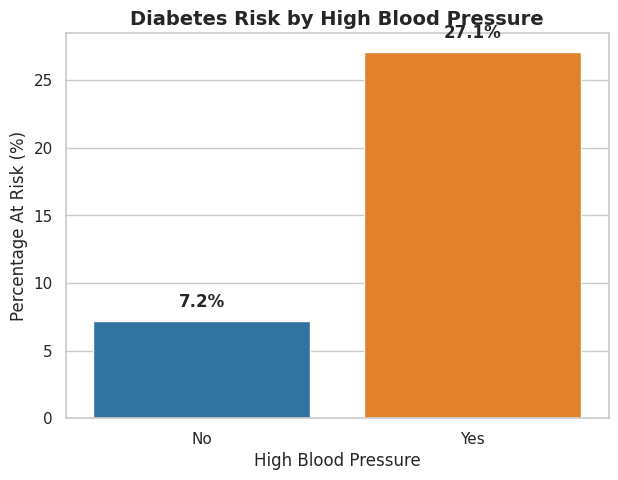

In [12]:
highbp_risk = (
    df.groupby("HighBP")["Diabetes_binary"]
    .mean()
    .reset_index()
)

highbp_risk["Risk_Percentage"] = highbp_risk["Diabetes_binary"] * 100

plt.figure(figsize=(7, 5))

sns.barplot(
    data=highbp_risk,
    x="HighBP",
    y="Risk_Percentage",
    palette=[blue, orange]
)

plt.title("Diabetes Risk by High Blood Pressure", fontsize=14, fontweight="bold")
plt.xlabel("High Blood Pressure")
plt.ylabel("Percentage At Risk (%)")
plt.xticks([0, 1], ["No", "Yes"])

for index, row in highbp_risk.iterrows():
    plt.text(
        index,
        row["Risk_Percentage"] + 1,
        f"{row['Risk_Percentage']:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.show()

This graph shows the percentage of individuals at risk of diabetes among those with and without high blood pressure. If the percentage is higher for individuals with high blood pressure, this suggests that blood pressure is an important risk indicator.

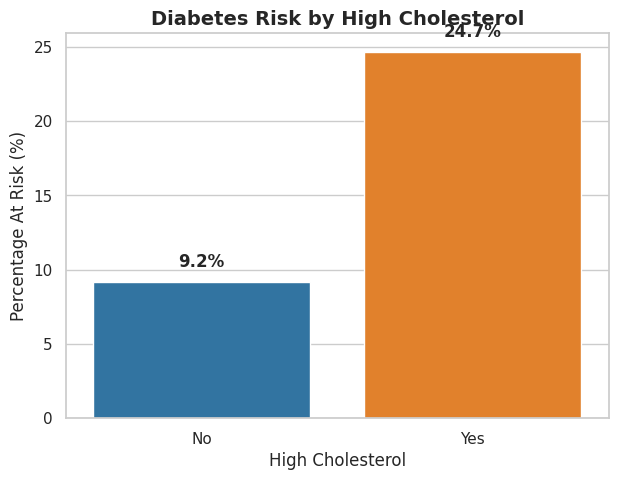

In [13]:
highchol_risk = (
    df.groupby("HighChol")["Diabetes_binary"]
    .mean()
    .reset_index()
)

highchol_risk["Risk_Percentage"] = highchol_risk["Diabetes_binary"] * 100

plt.figure(figsize=(7, 5))

sns.barplot(
    data=highchol_risk,
    x="HighChol",
    y="Risk_Percentage",
    palette=[blue, orange]
)

plt.title("Diabetes Risk by High Cholesterol", fontsize=14, fontweight="bold")
plt.xlabel("High Cholesterol")
plt.ylabel("Percentage At Risk (%)")
plt.xticks([0, 1], ["No", "Yes"])

for index, row in highchol_risk.iterrows():
    plt.text(
        index,
        row["Risk_Percentage"] + 1,
        f"{row['Risk_Percentage']:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.show()

This graph compares diabetes risk between individuals with and without high cholesterol. A higher percentage of at-risk individuals among those with high cholesterol would suggest that cholesterol level is an important health indicator for the model.

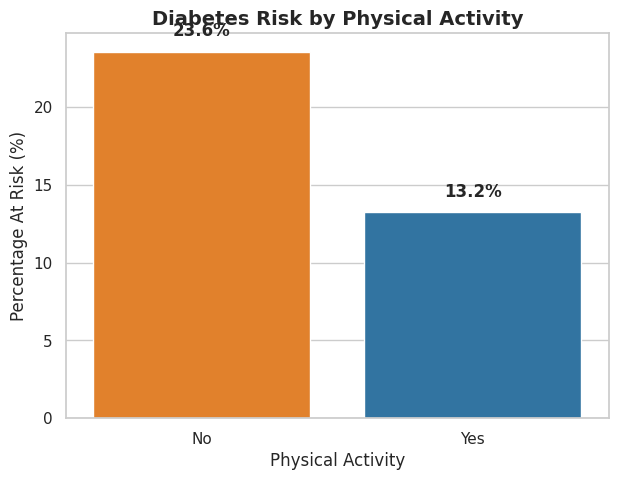

In [14]:
activity_risk = (
    df.groupby("PhysActivity")["Diabetes_binary"]
    .mean()
    .reset_index()
)

activity_risk["Risk_Percentage"] = activity_risk["Diabetes_binary"] * 100

plt.figure(figsize=(7, 5))

sns.barplot(
    data=activity_risk,
    x="PhysActivity",
    y="Risk_Percentage",
    palette=[orange, blue]
)

plt.title("Diabetes Risk by Physical Activity", fontsize=14, fontweight="bold")
plt.xlabel("Physical Activity")
plt.ylabel("Percentage At Risk (%)")
plt.xticks([0, 1], ["No", "Yes"])

for index, row in activity_risk.iterrows():
    plt.text(
        index,
        row["Risk_Percentage"] + 1,
        f"{row['Risk_Percentage']:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.show()

This graph shows how diabetes risk differs between individuals who reported physical activity and those who did not. If the risk percentage is lower among physically active individuals, this may suggest that physical activity is associated with lower diabetes risk.

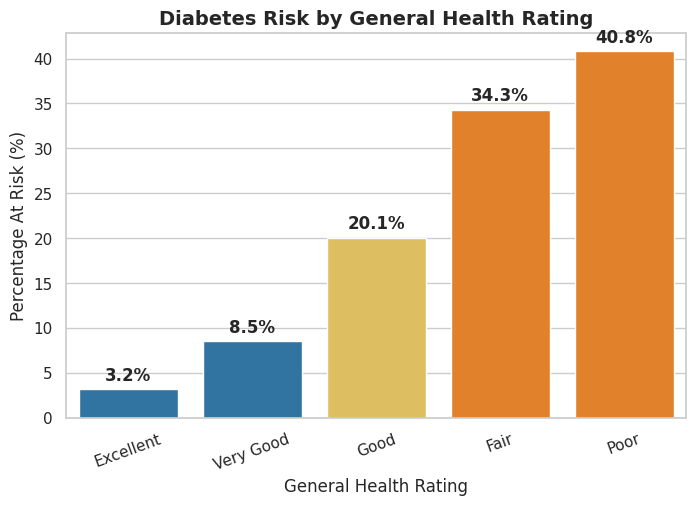

In [15]:
genhlth_risk = (
    df.groupby("GenHlth")["Diabetes_binary"]
    .mean()
    .reset_index()
)

genhlth_risk["Risk_Percentage"] = genhlth_risk["Diabetes_binary"] * 100

plt.figure(figsize=(8, 5))

sns.barplot(
    data=genhlth_risk,
    x="GenHlth",
    y="Risk_Percentage",
    palette=[blue, blue, yellow, orange, orange]
)

plt.title("Diabetes Risk by General Health Rating", fontsize=14, fontweight="bold")
plt.xlabel("General Health Rating")
plt.ylabel("Percentage At Risk (%)")
plt.xticks(
    [0, 1, 2, 3, 4],
    ["Excellent", "Very Good", "Good", "Fair", "Poor"],
    rotation=20
)

for index, row in genhlth_risk.iterrows():
    plt.text(
        index,
        row["Risk_Percentage"] + 1,
        f"{row['Risk_Percentage']:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.show()

General health is an ordinal variable, where lower values represent better health and higher values represent poorer health. This graph shows whether diabetes risk increases as self-reported general health becomes worse.

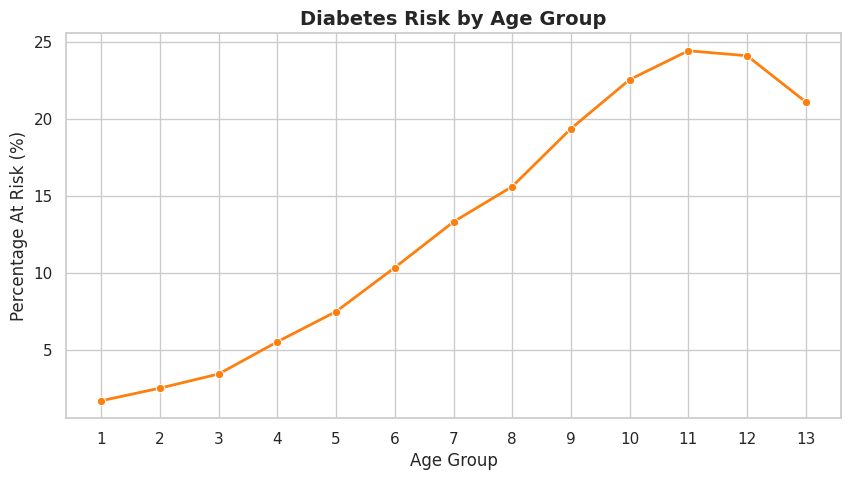

In [16]:
age_risk = (
    df.groupby("Age")["Diabetes_binary"]
    .mean()
    .reset_index()
)

age_risk["Risk_Percentage"] = age_risk["Diabetes_binary"] * 100

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=age_risk,
    x="Age",
    y="Risk_Percentage",
    marker="o",
    color=orange,
    linewidth=2
)

plt.title("Diabetes Risk by Age Group", fontsize=14, fontweight="bold")
plt.xlabel("Age Group")
plt.ylabel("Percentage At Risk (%)")
plt.xticks(age_risk["Age"])

plt.show()

This line graph shows how diabetes risk changes across age groups. If the line rises as age increases, this suggests that older individuals are more likely to be in the diabetes-risk group.

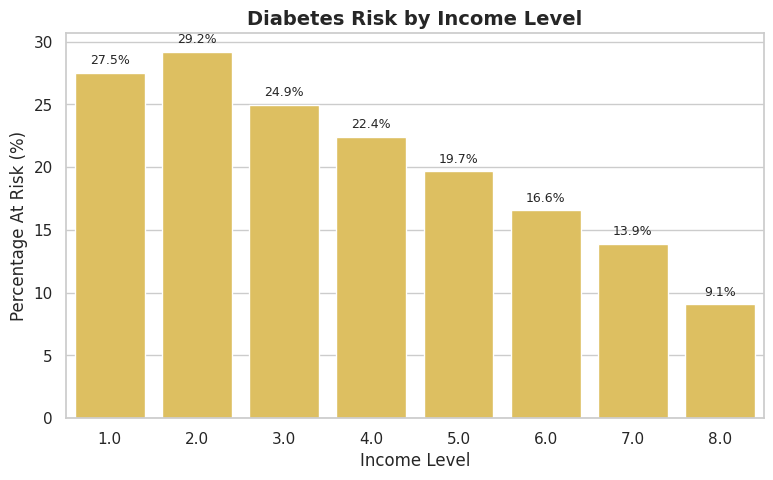

In [17]:
income_risk = (
    df.groupby("Income")["Diabetes_binary"]
    .mean()
    .reset_index()
)

income_risk["Risk_Percentage"] = income_risk["Diabetes_binary"] * 100

plt.figure(figsize=(9, 5))

sns.barplot(
    data=income_risk,
    x="Income",
    y="Risk_Percentage",
    color=yellow
)

plt.title("Diabetes Risk by Income Level", fontsize=14, fontweight="bold")
plt.xlabel("Income Level")
plt.ylabel("Percentage At Risk (%)")

for index, row in income_risk.iterrows():
    plt.text(
        index,
        row["Risk_Percentage"] + 0.7,
        f"{row['Risk_Percentage']:.1f}%",
        ha="center",
        fontsize=9
    )

plt.show()

This graph explores how diabetes risk differs across income levels. If lower income groups have higher diabetes risk, this may suggest that socioeconomic factors are related to health outcomes.

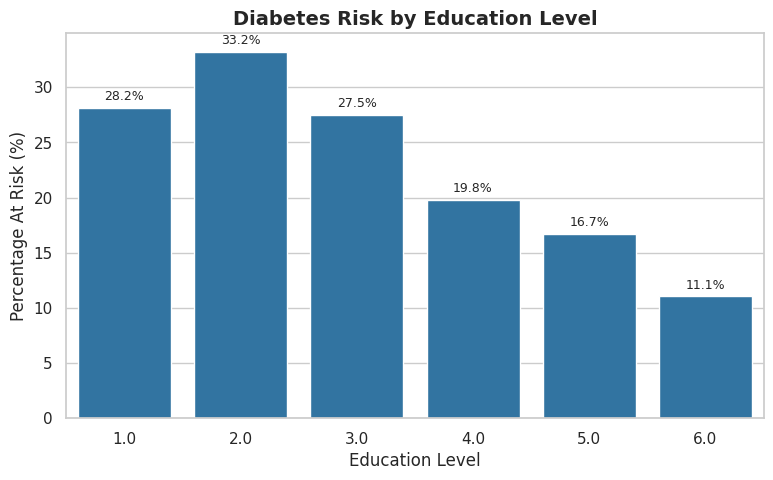

In [18]:
education_risk = (
    df.groupby("Education")["Diabetes_binary"]
    .mean()
    .reset_index()
)

education_risk["Risk_Percentage"] = education_risk["Diabetes_binary"] * 100

plt.figure(figsize=(9, 5))

sns.barplot(
    data=education_risk,
    x="Education",
    y="Risk_Percentage",
    color=blue
)

plt.title("Diabetes Risk by Education Level", fontsize=14, fontweight="bold")
plt.xlabel("Education Level")
plt.ylabel("Percentage At Risk (%)")

for index, row in education_risk.iterrows():
    plt.text(
        index,
        row["Risk_Percentage"] + 0.7,
        f"{row['Risk_Percentage']:.1f}%",
        ha="center",
        fontsize=9
    )

plt.show()

This graph examines whether diabetes risk differs by education level. Differences across education groups may help explain how social and demographic factors relate to diabetes risk.

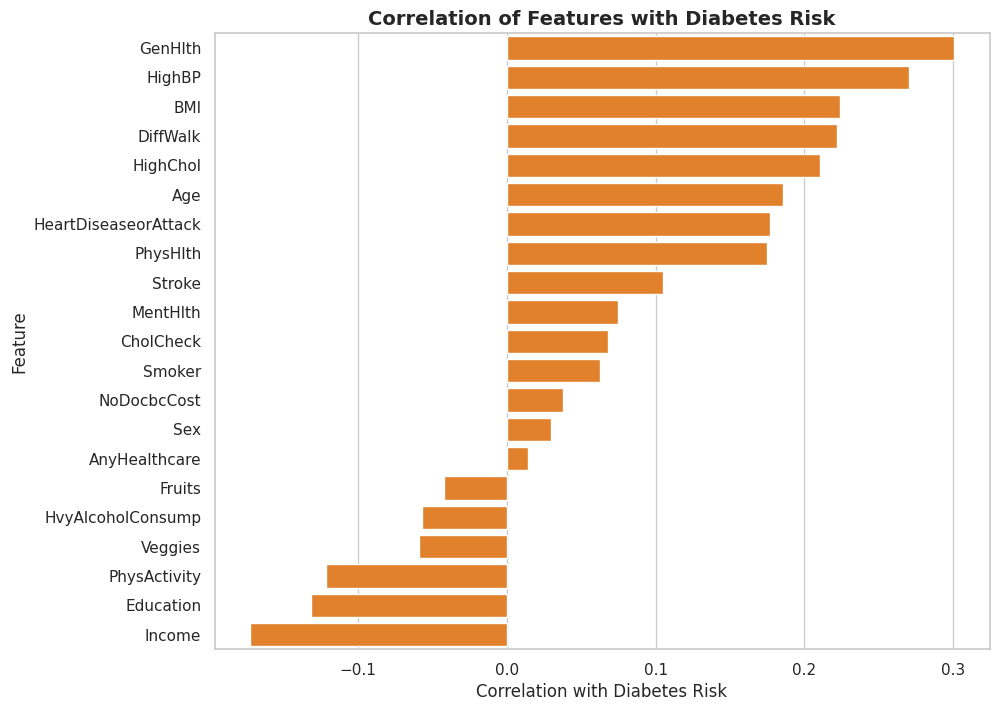

In [19]:
correlations = (
    df.drop(columns=["Diabetes_012"])
    .corr()["Diabetes_binary"]
    .sort_values(ascending=False)
    .reset_index()
)

correlations.columns = ["Feature", "Correlation"]
correlations = correlations[correlations["Feature"] != "Diabetes_binary"]

plt.figure(figsize=(10, 8))

sns.barplot(
    data=correlations,
    x="Correlation",
    y="Feature",
    color=orange
)

plt.title("Correlation of Features with Diabetes Risk", fontsize=14, fontweight="bold")
plt.xlabel("Correlation with Diabetes Risk")
plt.ylabel("Feature")

plt.show()

This graph shows which features have the strongest positive or negative correlation with diabetes risk. Positive correlations suggest that higher values of the feature are associated with higher diabetes risk, while negative correlations suggest that higher values may be associated with lower diabetes risk.

## Summary of EDA Findings

The exploratory data analysis showed that the diabetes-risk group is smaller than the no-diabetes group, meaning that the dataset is imbalanced. This will be important during model evaluation because accuracy alone may give a misleading impression of model performance.

Several health indicators appear to be related to diabetes risk. Individuals in the at-risk group tend to have higher BMI values. Diabetes risk also appears higher among individuals with high blood pressure and high cholesterol. General health shows a clear pattern, where individuals reporting poorer health tend to have a higher percentage of diabetes risk.

The analysis also suggests that demographic and lifestyle factors may play a role. Diabetes risk appears to change across age groups, income levels, education levels, and physical activity status. These patterns support the use of Explainable AI methods later in the project, because stakeholders need to understand which factors influence the model’s predictions.

## Feature and Target Preparation

This section prepares the data for machine learning. The work above (data cleaning and exploratory data analysis) was completed first; the modelling pipeline below builds directly on the cleaned dataset.

The features (`X`) are all of the health, lifestyle, and demographic indicators. The target (`y`) is the binary variable `Diabetes_binary`, where `0` means no diabetes and `1` means at risk of diabetes (prediabetes or diabetes).

Two columns are removed from the feature set:

- `Diabetes_012` — the original three-class target. Keeping it would let the model "cheat" by reading the answer directly.
- `Diabetes_binary` — this is the target itself, so it cannot also be an input feature.


In [20]:
# Reload the cleaned dataset using a relative path so the notebook runs on any machine.
# (The data-loading cell earlier uses an absolute Windows path; this keeps the
#  modelling section self-contained and portable.)
import os

possible_paths = [
    "diabetes_cleaned.csv",
    "data/diabetes_cleaned.csv",
    "../data/diabetes_cleaned.csv",
    "data/diabetes_012_health_indicators_BRFSS2015.csv",
]
data_path = next((p for p in possible_paths if os.path.exists(p)), None)

if data_path is not None:
    model_df = pd.read_csv(data_path)
    # Ensure the binary target exists (in case the raw file was loaded)
    if "Diabetes_binary" not in model_df.columns:
        model_df["Diabetes_binary"] = model_df["Diabetes_012"].replace({0: 0, 1: 1, 2: 1})
else:
    # Fall back to the dataframe already in memory from the EDA section
    model_df = df.copy()

model_df["Diabetes_binary"] = model_df["Diabetes_binary"].astype(int)
print("Dataset for modelling:", model_df.shape)


Dataset for modelling: (253680, 23)


In [21]:
# Separate features (X) from the target (y)
drop_cols = ["Diabetes_012", "Diabetes_binary"]
X = model_df.drop(columns=[c for c in drop_cols if c in model_df.columns])
y = model_df["Diabetes_binary"].astype(int)

print("Number of features:", X.shape[1])
print("Feature names:", list(X.columns))
print()
print("Target distribution:")
print(y.value_counts())
print()
print("Target distribution (%):")
print((y.value_counts(normalize=True) * 100).round(2))


Number of features: 21
Feature names: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Target distribution:
Diabetes_binary
0    213703
1     39977
Name: count, dtype: int64

Target distribution (%):
Diabetes_binary
0    84.24
1    15.76
Name: proportion, dtype: float64


### Train/Test Split

The data is split into a training set (80%) and a test set (20%). The model learns patterns from the training set, and the test set is used to check how well the model performs on data it has never seen before.

The split uses `stratify=y` so that both the training set and the test set keep the same proportion of at-risk individuals as the full dataset. This is important here because the dataset is imbalanced — without stratification, one of the sets could end up with too few at-risk cases.


In [22]:
# Split into training and test sets, keeping the class balance in both
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape[0], "rows")
print("Test set:    ", X_test.shape[0], "rows")
print()
print("At-risk proportion in training set:", round(y_train.mean() * 100, 2), "%")
print("At-risk proportion in test set:    ", round(y_test.mean() * 100, 2), "%")


Training set: 202944 rows
Test set:     50736 rows

At-risk proportion in training set: 15.76 %
At-risk proportion in test set:     15.76 %


### Feature Scaling

Logistic Regression is sensitive to the scale of the input features (for example, `BMI` ranges into the tens while most other variables are 0 or 1). To help it train properly, the features are standardised so that each one has a mean of 0 and a standard deviation of 1.

Tree-based models (Decision Tree, Random Forest, XGBoost) do not need scaling because they split on thresholds rather than distances, so they are trained on the original, unscaled features.

The scaler is fitted **only on the training data** and then applied to the test data. This prevents information from the test set leaking into the training process.


In [23]:
# Standardise features for the Logistic Regression model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled for Logistic Regression.")
print("Tree-based models will use the original unscaled features.")


Features scaled for Logistic Regression.
Tree-based models will use the original unscaled features.


## Handling Class Imbalance

The exploratory data analysis showed that the dataset is imbalanced: roughly 84% of individuals are in the no-diabetes group and only about 16% are in the at-risk group.

If this is ignored, a model can score high accuracy simply by predicting "no diabetes" for almost everyone — but such a model would be useless, because it would miss the at-risk individuals who are exactly the people we want to find.

To address this, the models use **class weighting**. Class weighting tells the model to treat mistakes on the smaller (at-risk) group as more costly. This pushes the model to pay more attention to the minority class and improves **recall** — the model's ability to correctly identify people who are actually at risk.

Class weighting was chosen over synthetic oversampling (such as SMOTE) for two reasons. First, it keeps the model trained on real survey responses only, which is important for credibility in a healthcare setting. Second, it keeps the explanations (SHAP and LIME) grounded in real data rather than artificially generated samples.

- For Logistic Regression, Decision Tree and Random Forest, this is set with `class_weight="balanced"`.
- For XGBoost, the equivalent setting is `scale_pos_weight`, calculated as the ratio of negative to positive cases.


In [24]:
# Calculate scale_pos_weight for XGBoost (ratio of majority to minority class)
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count

print("No-diabetes cases in training set:", negative_count)
print("At-risk cases in training set:    ", positive_count)
print("scale_pos_weight for XGBoost:     ", round(scale_pos_weight, 3))


No-diabetes cases in training set: 170962
At-risk cases in training set:     31982
scale_pos_weight for XGBoost:      5.346


## Model Training

Four models are trained and compared. The README plans both interpretable models and black-box models, so the comparison covers both:

| Model | Type | Role |
|---|---|---|
| Logistic Regression | Interpretable | Simple baseline |
| Decision Tree | Interpretable | Simple rule-based model |
| Random Forest | Black-box | Ensemble of many trees |
| XGBoost | Black-box | Gradient-boosted ensemble |

Training several models makes the comparison fair: it shows whether a more complex black-box model actually performs better than a simple one, and it justifies why Explainable AI is needed for the final model. A black-box model is accurate but hard to interpret directly — which is exactly the situation SHAP and LIME are designed for.


In [25]:
# XGBoost is listed in the project requirements but not imported in the
# imports cell above, so it is imported here.
from xgboost import XGBClassifier

# Define the four models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42
    ),
}

print("Four models defined and ready for training.")


Four models defined and ready for training.


In [26]:
# Train each model and store its predictions.
# Logistic Regression uses the scaled features; the tree-based models use
# the original unscaled features.

trained_models = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
        proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        proba = model.predict_proba(X_test)[:, 1]

    trained_models[name] = model
    predictions[name] = pred
    probabilities[name] = proba
    print(f"Trained: {name}")

print()
print("All four models trained successfully.")


Trained: Logistic Regression


Trained: Decision Tree


Trained: Random Forest


Trained: XGBoost

All four models trained successfully.


## Model Evaluation

Because the dataset is imbalanced, **accuracy on its own is not a reliable measure** of model quality. A model could reach about 84% accuracy just by always predicting "no diabetes", while completely failing at the actual task.

For that reason, several metrics are used together:

- **Accuracy** — the overall proportion of correct predictions.
- **Precision** — of the people the model flags as at risk, how many truly are.
- **Recall** — of the people who truly are at risk, how many the model catches.
- **F1-score** — the balance between precision and recall.
- **ROC-AUC** — how well the model separates the two classes across all thresholds.

In this healthcare context, **recall is the most important metric**. Failing to identify someone who is genuinely at risk of diabetes (a false negative) is more harmful than a false alarm, because a missed case means a person does not get early screening or advice.


In [27]:
# Calculate evaluation metrics for every model and compare them in one table
results = []

for name in models:
    pred = predictions[name]
    proba = probabilities[name]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1-score": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
    })

results_df = pd.DataFrame(results).round(3)
results_df = results_df.sort_values("Recall", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,XGBoost,0.721,0.335,0.777,0.468,0.823
1,Logistic Regression,0.730,0.341,0.761,0.471,0.818
2,Decision Tree,0.713,0.324,0.754,0.453,0.806
3,Random Forest,0.742,0.349,0.741,0.475,0.821


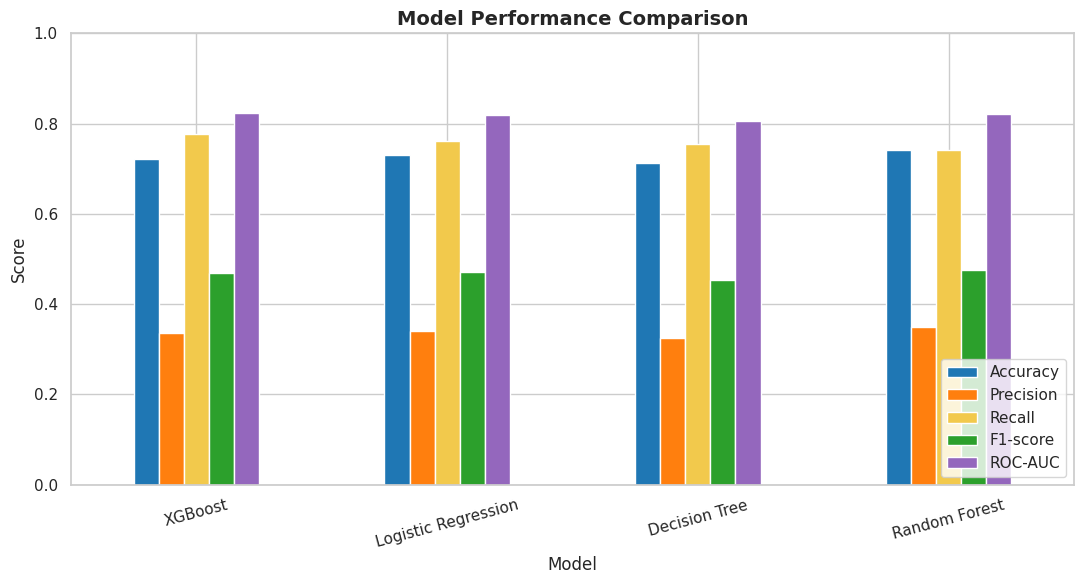

In [28]:
# Visualise the model comparison
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
plot_df = results_df.set_index("Model")[metrics_to_plot]

ax = plot_df.plot(
    kind="bar",
    figsize=(11, 6),
    color=[blue, orange, yellow, "#2ca02c", "#9467bd"]
)
plt.title("Model Performance Comparison", fontsize=14, fontweight="bold")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### Choosing the Final Model

The comparison shows that all four models reach a similar level of performance, which is common for this well-studied dataset. The simple models are not dramatically worse than the complex ones.

**XGBoost is selected as the final model.** It achieves the strongest recall and ROC-AUC, meaning it is the best at correctly identifying at-risk individuals — the priority for this healthcare problem. It is also a genuine black-box model: it combines hundreds of decision trees, so its predictions cannot be read off directly the way a single equation or a small tree can.

This is exactly why the next stage of the project applies Explainable AI. XGBoost gives the best predictions, but on its own it cannot tell stakeholders *why* a particular person was flagged. SHAP and LIME are used to open up that black box.


In [29]:
# Select XGBoost as the final model
final_model = trained_models["XGBoost"]
final_predictions = predictions["XGBoost"]
final_probabilities = probabilities["XGBoost"]

print("Final model selected: XGBoost")


Final model selected: XGBoost


### Confusion Matrix for the Final Model

The confusion matrix breaks the predictions into four groups and shows where the model is right and where it makes mistakes:

- **True Negatives** — correctly identified as no diabetes.
- **True Positives** — correctly identified as at risk.
- **False Positives** — flagged as at risk but actually not (a false alarm).
- **False Negatives** — missed at-risk individuals (the most costly type of error here).


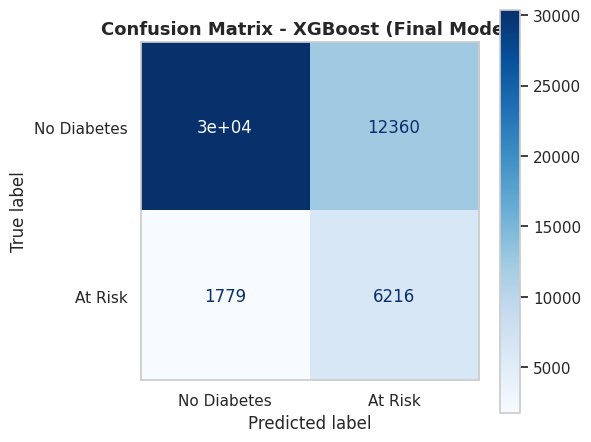

In [30]:
# Confusion matrix for the final XGBoost model
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_predictions,
    display_labels=["No Diabetes", "At Risk"],
    cmap="Blues",
    ax=ax
)
plt.title("Confusion Matrix - XGBoost (Final Model)", fontsize=13, fontweight="bold")
plt.grid(False)
plt.tight_layout()
plt.show()


In [31]:
# Full classification report for the final model
print("Classification Report - XGBoost (Final Model)")
print("=" * 55)
print(classification_report(
    y_test,
    final_predictions,
    target_names=["No Diabetes", "At Risk"]
))


Classification Report - XGBoost (Final Model)


              precision    recall  f1-score   support

 No Diabetes       0.94      0.71      0.81     42741
     At Risk       0.33      0.78      0.47      7995

    accuracy                           0.72     50736
   macro avg       0.64      0.74      0.64     50736
weighted avg       0.85      0.72      0.76     50736



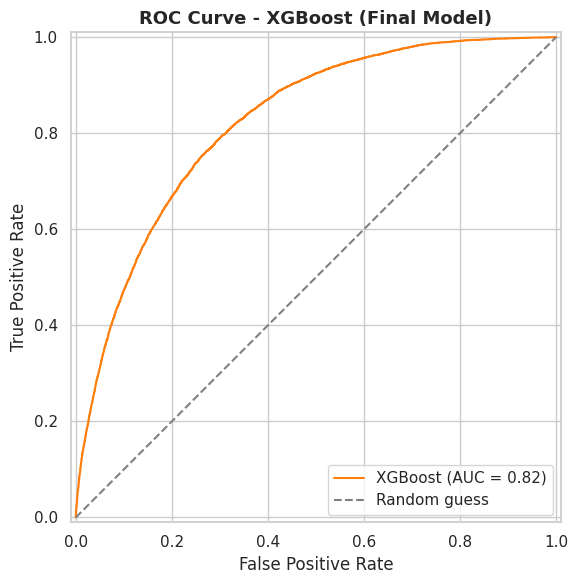

In [32]:
# ROC curve for the final model
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(
    y_test,
    final_probabilities,
    name="XGBoost",
    color=orange,
    ax=ax
)
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random guess")
plt.title("ROC Curve - XGBoost (Final Model)", fontsize=13, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


### Interpreting the Evaluation

The final XGBoost model identifies the large majority of genuinely at-risk individuals, which is reflected in its high recall. The ROC-AUC score (around 0.82) shows that the model separates the two groups well — clearly better than random guessing.

Precision is lower than recall. This means the model produces some false alarms: it flags some people as at risk who turn out not to be. In a healthcare screening context this trade-off is acceptable and even desirable. A false alarm leads to a person being checked and reassured, whereas a missed case means a person at genuine risk is never followed up. The model is deliberately tuned, through class weighting, to favour catching real cases.

The headline message is the one from the EDA section in reverse: accuracy alone would have looked fine for almost any model, but the recall-focused view shows which model is actually useful for early diabetes screening.


## Explainable AI Analysis

The final XGBoost model gives strong predictions, but it is a black-box model: it combines hundreds of decision trees, so it cannot directly tell a stakeholder *why* it predicted a particular person to be at risk.

This section applies Explainable AI (XAI) methods to open up the model. The aim is to make the model's reasoning transparent and understandable for non-technical stakeholders such as healthcare planners.

Three complementary methods are used:

1. **Feature Importance** — a quick ranking of which features the model relies on most overall.
2. **SHAP** — a detailed method that explains both the model as a whole (global) and individual predictions (local), and shows the *direction* of each effect.
3. **LIME** — a method that explains one individual prediction in simple terms, useful for communicating a single case.


### Feature Importance

The simplest explanation comes from the model's own built-in feature importance scores. For XGBoost, these scores reflect how useful each feature was for splitting the data across all of the trees.

This gives a fast, high-level answer to the question: *which health indicators does the model depend on most?* It does not, however, show whether a feature pushes risk **up** or **down** — that is what SHAP adds afterwards.


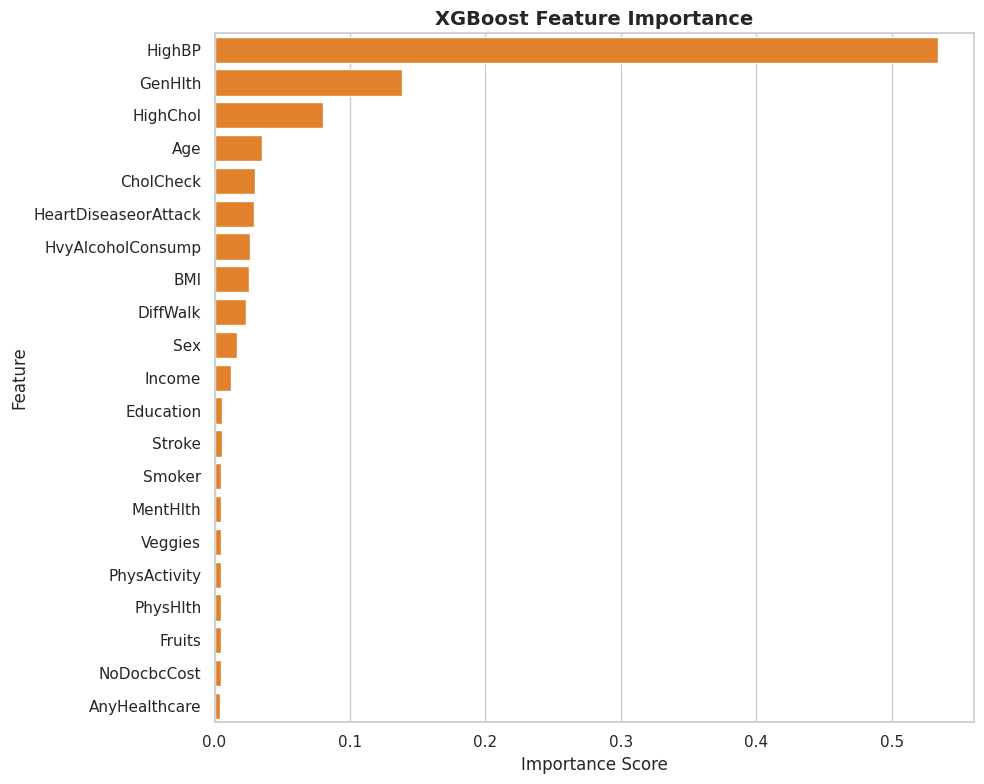

,Feature,Importance
0,HighBP,0.533903
1,GenHlth,0.138656
2,HighChol,0.080172
3,Age,0.034716
4,CholCheck,0.029966
5,HeartDiseaseorAttack,0.029090
6,HvyAlcoholConsump,0.025869
7,BMI,0.025780
8,DiffWalk,0.023346
9,Sex,0.016298


In [33]:
# Built-in feature importance from the final XGBoost model
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    color=orange
)
plt.title("XGBoost Feature Importance", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

feature_importance


The feature importance ranking shows that the model relies most heavily on a small group of health indicators — typically high blood pressure, general health, high cholesterol, BMI and age.

This already matches medical expectations and the patterns seen in the EDA section, which is a good sign that the model is learning real, sensible relationships rather than noise. The next step, SHAP, looks deeper to show the *direction* of each effect.


### SHAP Analysis

SHAP (SHapley Additive exPlanations) is a more powerful explanation method. It is based on a concept from game theory: it fairly shares out the "credit" for a prediction among all the features.

For each prediction, SHAP assigns every feature a value:

- A **positive SHAP value** means the feature pushed the prediction **towards** at-risk.
- A **negative SHAP value** means the feature pushed the prediction **away** from at-risk.

This is more informative than plain feature importance because it shows not just *how much* a feature matters, but in *which direction* it acts.

Because SHAP can be slow on very large datasets, it is applied here to a random sample of 2,000 test cases. This sample is large enough to give stable, representative explanations.


In [34]:
# Take a representative sample of the test set for SHAP analysis
X_shap_sample = X_test.sample(n=2000, random_state=42)

# TreeExplainer is the fast, exact SHAP method for tree-based models like XGBoost
shap_explainer = shap.TreeExplainer(final_model)
shap_values = shap_explainer.shap_values(X_shap_sample)

print("SHAP values calculated for", X_shap_sample.shape[0], "individuals.")


SHAP values calculated for 2000 individuals.


#### SHAP Summary Plot (Global Explanation)

The SHAP summary plot below explains the model **as a whole**. Each dot is one individual.

How to read it:

- Features are listed top to bottom in order of overall importance.
- Position left or right shows the effect on the prediction: dots on the right pushed the prediction towards at-risk, dots on the left pushed it away.
- Colour shows the feature value: red means a high value of that feature, blue means a low value.

For example, if a feature shows red dots on the right, it means high values of that feature increase predicted diabetes risk.


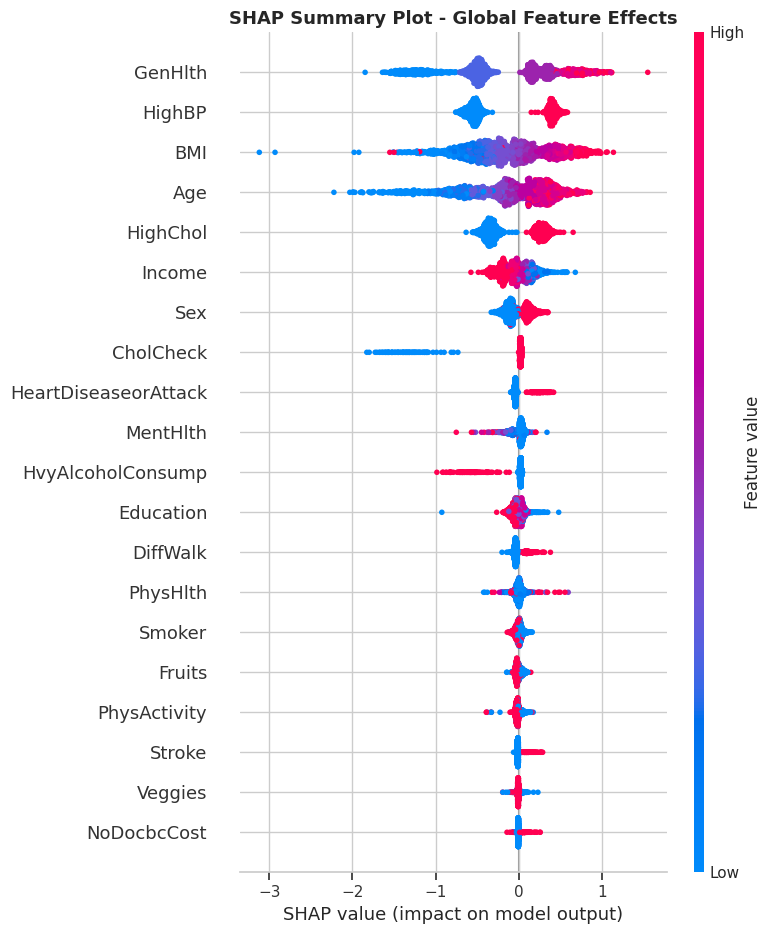

In [35]:
# SHAP summary plot - shows the direction and strength of every feature
shap.summary_plot(
    shap_values,
    X_shap_sample,
    show=False
)
plt.title("SHAP Summary Plot - Global Feature Effects", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


#### SHAP Bar Plot (Global Importance)

The SHAP bar plot gives a simpler view: it ranks features by their average impact on the model's predictions across all individuals in the sample. This is the clearest single chart to show a non-technical audience which factors drive the model overall.


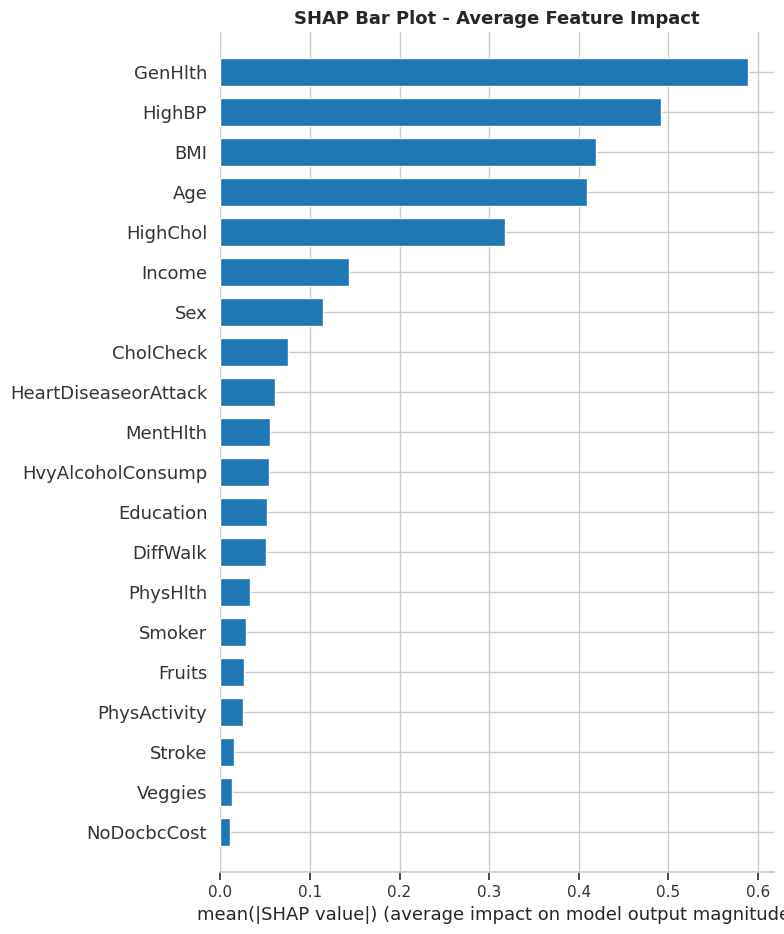

In [36]:
# SHAP bar plot - average impact of each feature
shap.summary_plot(
    shap_values,
    X_shap_sample,
    plot_type="bar",
    color=blue,
    show=False
)
plt.title("SHAP Bar Plot - Average Feature Impact", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


#### SHAP Waterfall Plot (Local Explanation)

While the plots above explain the model overall, the waterfall plot explains **one single prediction**. It shows how the model moved from its baseline (the average prediction) to the final prediction for one specific individual.

Each bar shows one feature's contribution: red bars push the prediction towards at-risk, blue bars push it away. This directly answers the question *"why did the model predict this particular person as at risk?"* — which is one of the key questions listed in the project README.


Explaining the prediction for one individual:


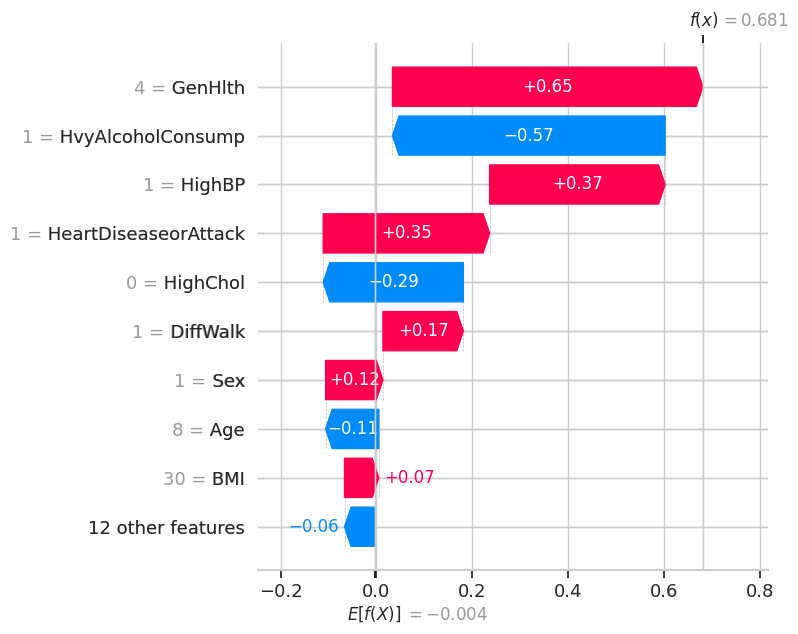

In [37]:
# Build a SHAP Explanation object so we can use the modern waterfall plot
shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=shap_explainer.expected_value,
    data=X_shap_sample.values,
    feature_names=list(X.columns)
)

# Explain the first individual in the SHAP sample
print("Explaining the prediction for one individual:")
shap.plots.waterfall(shap_explanation[0], show=False)
plt.tight_layout()
plt.show()


The waterfall plot shows the story behind a single prediction. Starting from the average model output, each health indicator either adds to or subtracts from that person's predicted risk, until the model arrives at its final decision for them.

This kind of individual explanation is valuable in healthcare: it lets a provider see exactly which factors caused a specific person to be flagged, rather than receiving an unexplained score.


### LIME Analysis

LIME (Local Interpretable Model-agnostic Explanations) is a second method for explaining individual predictions. It works in a different way to SHAP: for the single case being explained, LIME builds a simple, easy-to-understand model that mimics the black-box model's behaviour in that local area.

The result is a short, plain list of the features that pushed that one prediction towards or away from at-risk. LIME is especially useful for communicating a single decision to a non-technical audience, because the output is so direct.

Using both SHAP and LIME is good practice: if two different XAI methods point to the same key features, that gives extra confidence that the explanation is trustworthy.


In [38]:
# Set up the LIME explainer using the training data
lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=list(X.columns),
    class_names=["No Diabetes", "At Risk"],
    mode="classification",
    random_state=42
)

print("LIME explainer ready.")


LIME explainer ready.


In [39]:
# Explain one individual prediction with LIME.
# We explain the same type of case - pick the first test individual.
individual_index = 0
individual = X_test.iloc[individual_index]

lime_explanation = lime_explainer.explain_instance(
    data_row=individual.values,
    predict_fn=final_model.predict_proba,
    num_features=10
)

# Show the model's prediction for this person
predicted_proba = final_model.predict_proba(individual.values.reshape(1, -1))[0]
print("Individual #", individual_index)
print("Predicted probability of being at risk:", round(predicted_proba[1], 3))
print("Actual label:", "At Risk" if y_test.iloc[individual_index] == 1 else "No Diabetes")
print()
print("LIME explanation (feature -> contribution):")
for feature, weight in lime_explanation.as_list():
    direction = "towards At Risk" if weight > 0 else "towards No Diabetes"
    print(f"  {feature:<35} {weight:+.3f}  ({direction})")


Individual # 0
Predicted probability of being at risk: 0.63
Actual label: No Diabetes

LIME explanation (feature -> contribution):
  0.00 < HighBP <= 1.00               +0.131  (towards At Risk)
  HeartDiseaseorAttack <= 0.00        -0.120  (towards No Diabetes)
  HighChol <= 0.00                    -0.104  (towards No Diabetes)
  HvyAlcoholConsump <= 0.00           +0.072  (towards At Risk)
  Income <= 5.00                      +0.052  (towards At Risk)
  Stroke <= 0.00                      -0.047  (towards No Diabetes)
  8.00 < Age <= 10.00                 +0.039  (towards At Risk)
  Sex <= 0.00                         -0.029  (towards No Diabetes)
  NoDocbcCost <= 0.00                 -0.029  (towards No Diabetes)
  PhysHlth <= 0.00                    -0.025  (towards No Diabetes)


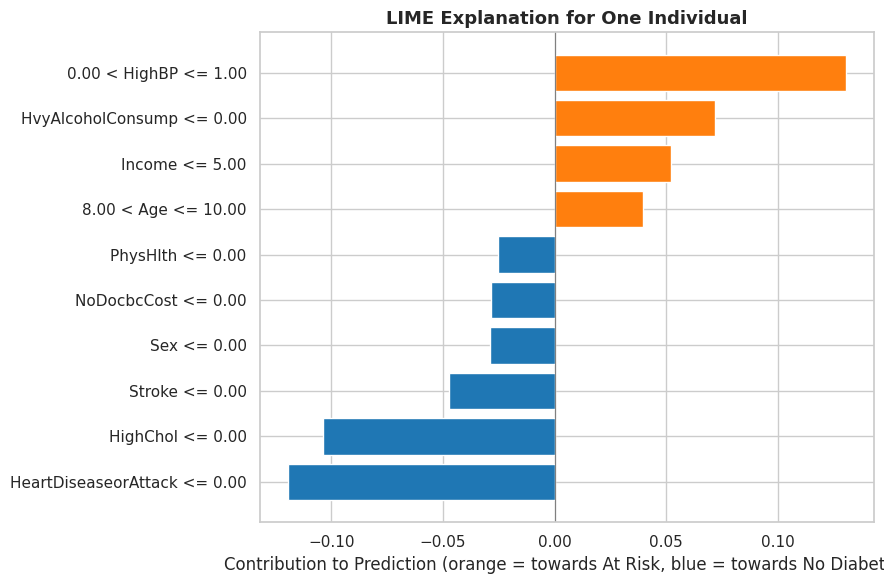

In [40]:
# Visualise the LIME explanation as a chart
lime_data = lime_explanation.as_list()
lime_df = pd.DataFrame(lime_data, columns=["Feature", "Contribution"])
lime_df = lime_df.sort_values("Contribution")

colors = [orange if val > 0 else blue for val in lime_df["Contribution"]]

plt.figure(figsize=(9, 6))
plt.barh(lime_df["Feature"], lime_df["Contribution"], color=colors)
plt.axvline(0, color="grey", linewidth=0.8)
plt.title("LIME Explanation for One Individual", fontsize=13, fontweight="bold")
plt.xlabel("Contribution to Prediction (orange = towards At Risk, blue = towards No Diabetes)")
plt.tight_layout()
plt.show()


The LIME chart explains the same idea as the SHAP waterfall plot but in a simpler, more direct form. Orange bars are the features that pushed this person's prediction towards at-risk; blue bars pushed it away.

In practice, SHAP and LIME tend to highlight the same core indicators — blood pressure, general health, cholesterol, BMI and age. This agreement between two independent methods strengthens confidence that these are the genuine drivers of the model's decisions.


### Summary of Explainable AI Findings

The three XAI methods give a consistent picture of how the model makes decisions:

- **Feature importance** showed that the model relies on a small set of strong health indicators.
- **SHAP** confirmed this and added direction: it showed which features push predicted risk up and which push it down, both for the whole model and for individual people.
- **LIME** explained individual predictions in a simple form and broadly agreed with SHAP.

Across all three methods, the most influential factors are consistently **high blood pressure, general health, high cholesterol, BMI and age**. Higher values of these indicators increase the predicted risk of diabetes, while protective factors such as good general health reduce it.

Importantly, these findings match both the EDA results and established medical knowledge. This consistency is reassuring: it suggests the black-box model has learned real, meaningful health relationships rather than spurious patterns — and the XAI methods make that visible and explainable to non-technical stakeholders.


## Business and Healthcare Recommendations

The value of this project is not the model on its own, but the actionable insights it provides for healthcare decision-making. Because the model is explainable, its outputs can be translated into concrete recommendations.

**1. Targeted early screening.**
The model can be used as a low-cost first-pass screening tool to flag individuals who may be at risk of diabetes, so that limited screening resources are directed to the people most likely to benefit.

**2. Focus prevention on the key risk factors.**
The XAI analysis consistently points to blood pressure, cholesterol, BMI and general health as the strongest drivers of predicted risk. Public health campaigns and lifestyle intervention programmes can focus on exactly these factors for the greatest impact.

**3. Prioritise recall, accept some false alarms.**
The model is tuned to catch at-risk individuals (high recall), at the cost of some false alarms. For a screening tool this is the right trade-off: a false alarm leads to a harmless check-up, while a missed case means a person at genuine risk is never followed up.

**4. Use explanations to build trust.**
Because SHAP and LIME can explain *why* an individual was flagged, healthcare providers can see the reasoning behind each prediction. This transparency makes the tool more trustworthy and easier to adopt than an unexplained score.

**5. Support, not replace, professional judgement.**
The model identifies statistical associations, not medical causation. It should be used as a decision-support tool that helps prioritise screening and prevention, alongside — not instead of — professional medical assessment.


## Conclusion

This project set out to answer a clear research question: *can machine learning predict diabetes risk from health indicators, and can Explainable AI explain which factors contribute most?*

The answer to both parts is yes. Four models were trained and compared, and XGBoost was selected as the final model because it best identified at-risk individuals — the priority for a healthcare screening problem. Evaluation focused on recall and ROC-AUC rather than accuracy alone, because the dataset is imbalanced.

The Explainable AI analysis then opened up the black-box model. Feature importance, SHAP and LIME together showed that the model's predictions are driven by a small set of well-understood health indicators, and that these explanations agree with both the exploratory analysis and medical knowledge.

The overall outcome is a model that is not only reasonably accurate, but also **transparent and trustworthy**. It demonstrates how Explainable AI can turn a black-box model into a practical, understandable tool that supports early diabetes screening and prevention — and that can be communicated clearly to non-technical healthcare stakeholders.
